# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.random import set_seed

from sklearn.model_selection import train_test_split


2026-04-26 19:21:29.336355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777231289.822238      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777231289.954196      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777231290.900015      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777231290.900058      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777231290.900061      55 computation_placer.cc:177] computation placer alr

# Load Dataset


In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/meetnagadia/bitcoin-stock-data-sept-17-2014-august-24-2021/BTC-USD.csv",
    index_col="Date",
    parse_dates=["Date"]
)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2713 entries, 2014-09-17 to 2022-02-19
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2713 non-null   float64
 1   High       2713 non-null   float64
 2   Low        2713 non-null   float64
 3   Close      2713 non-null   float64
 4   Adj Close  2713 non-null   float64
 5   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 148.4 KB
None
               Open          High           Low         Close     Adj Close  \
count   2713.000000   2713.000000   2713.000000   2713.000000   2713.000000   
mean   11311.041069  11614.292482  10975.555057  11323.914637  11323.914637   
std    16106.428891  16537.390649  15608.572560  16110.365010  16110.365010   
min      176.897003    211.731003    171.509995    178.102997    178.102997   
25%      606.396973    609.260986    604.109985    606.718994    606.718994   
50%     6301.569824   643

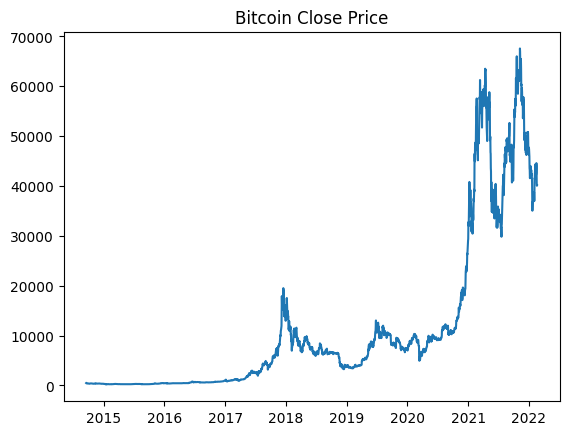

In [5]:
import matplotlib.pyplot as plt

plt.plot(df["Close"])
plt.title("Bitcoin Close Price")
plt.show()

In [6]:
data = df["Close"].values 
data = data.reshape(-1,1)

# Scaling

In [7]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
data = sc.fit_transform(data)

# Sequence creation

In [8]:
X = []
y = []

n_steps = 30

for i in range(n_steps, len(data)):
    X.append(data[i-n_steps:i])
    y.append(data[i])

import numpy as np
X = np.array(X)
y = np.array(y)

In [9]:
X

array([[[0.00414359],
        [0.00365546],
        [0.00321557],
        ...,
        [0.0033057 ],
        [0.00321523],
        [0.00303393]],

       [[0.00365546],
        [0.00321557],
        [0.00342492],
        ...,
        [0.00321523],
        [0.00303393],
        [0.00305177]],

       [[0.00321557],
        [0.00342492],
        [0.0032753 ],
        ...,
        [0.00303393],
        [0.00305177],
        [0.0031658 ]],

       ...,

       [[0.62618086],
        [0.61681275],
        [0.6010251 ],
        ...,
        [0.62931618],
        [0.65882089],
        [0.64971932]],

       [[0.61681275],
        [0.6010251 ],
        [0.53835732],
        ...,
        [0.65882089],
        [0.64971932],
        [0.59891189]],

       [[0.6010251 ],
        [0.53835732],
        [0.51718068],
        ...,
        [0.64971932],
        [0.59891189],
        [0.59138785]]])

In [10]:
y

array([[0.00305177],
       [0.0031658 ],
       [0.00313766],
       ...,
       [0.59891189],
       [0.59138785],
       [0.59280431]])

# Train/Test split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train

array([[[0.00414359],
        [0.00365546],
        [0.00321557],
        ...,
        [0.0033057 ],
        [0.00321523],
        [0.00303393]],

       [[0.00365546],
        [0.00321557],
        [0.00342492],
        ...,
        [0.00321523],
        [0.00303393],
        [0.00305177]],

       [[0.00321557],
        [0.00342492],
        [0.0032753 ],
        ...,
        [0.00303393],
        [0.00305177],
        [0.0031658 ]],

       ...,

       [[0.16223947],
        [0.16538915],
        [0.17186094],
        ...,
        [0.16783609],
        [0.16538812],
        [0.16863944]],

       [[0.16538915],
        [0.17186094],
        [0.16138473],
        ...,
        [0.16538812],
        [0.16863944],
        [0.16811065]],

       [[0.17186094],
        [0.16138473],
        [0.16424477],
        ...,
        [0.16863944],
        [0.16811065],
        [0.17114737]]])

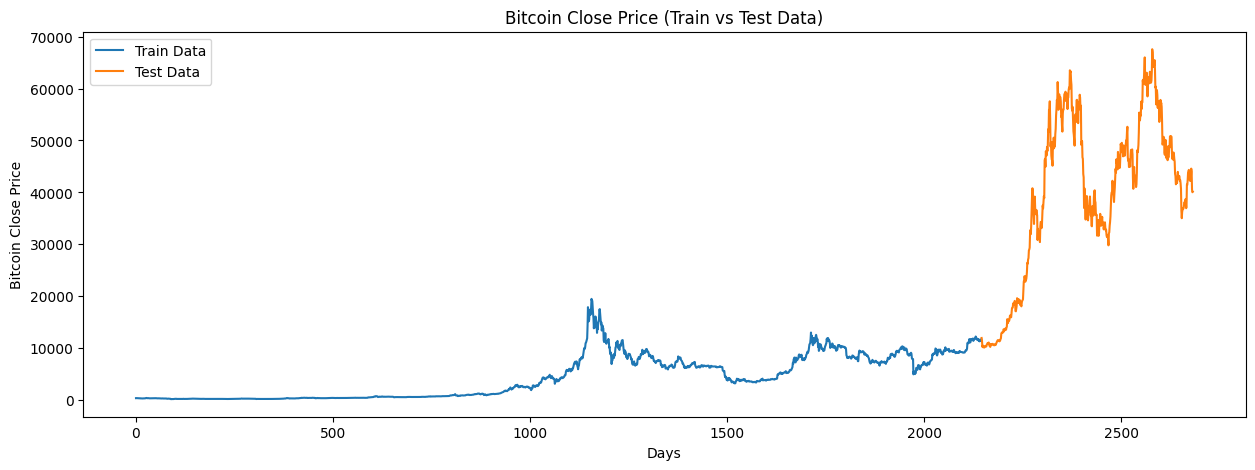

In [17]:
# convert scaled values back for plotting
train_plot = sc.inverse_transform(y_train)
test_plot = sc.inverse_transform(y_test)

# plot train and test data first
plt.figure(figsize=(15,5))

# plot training data
plt.plot(range(len(train_plot)), train_plot, label="Train Data")

# plot testing data after train data
plt.plot(
    range(len(train_plot), len(train_plot)+len(test_plot)),
    test_plot,
    label="Test Data"
)

# title
plt.title("Bitcoin Close Price (Train vs Test Data)")
# labels
plt.xlabel("Days")
plt.ylabel("Bitcoin Close Price")
# legend
plt.legend()

# show graph
plt.show()

# Build SIMPLE RNN

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
model = Sequential()

model.add(SimpleRNN(50, activation="tanh", input_shape=(30,1)))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.summary()

I0000 00:00:1777231626.425909      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777231626.431994      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

# Train model

In [16]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


I0000 00:00:1777231680.442925     150 service.cc:152] XLA service 0x798f28004d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777231680.442964     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777231680.442968     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777231680.777648     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


33/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012

I0000 00:00:1777231681.768453     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 8.1724e-04
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0127e-04
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.5075e-05
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.1738e-05
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.3570e-05
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5003e-05
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1087e-05
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6078e-05
Epoch 9/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4239e-05
Epoch 10/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5786e-05


# MODEL PREDICTION & PERFORMANCE EVALUATION 

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


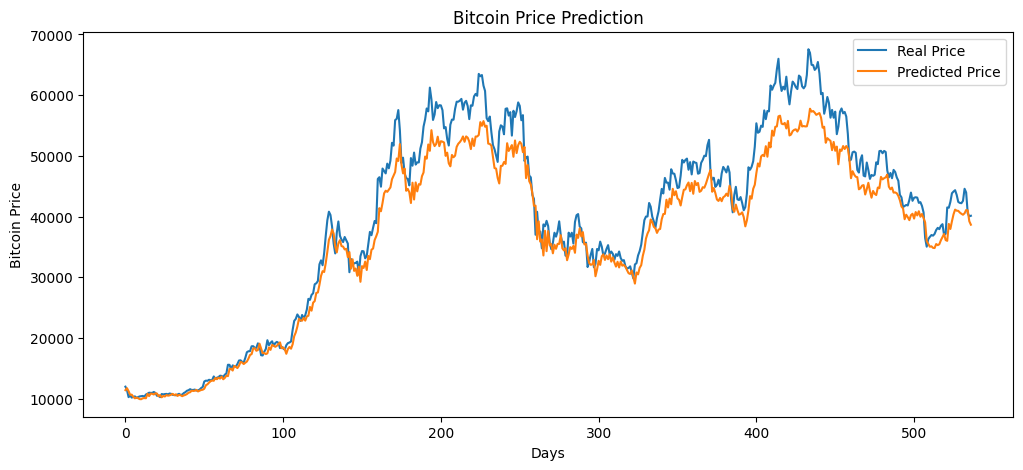

RMSE: 3898.6527584303108


In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# prediction
pred = model.predict(X_test)

# convert back to original scale
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)

# plot results
plt.figure(figsize=(12,5))
plt.plot(real, label="Real Price")
plt.plot(pred, label="Predicted Price")
plt.title("Bitcoin Price Prediction")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price")
plt.legend()
plt.show()

# error (RMSE)
rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)

# LSTM

In [20]:
# LSTM Model
model = Sequential()
model.add(LSTM(125, activation="tanh", input_shape=(60,1)))
model.add(Dense(1))

model.compile(optimizer="RMSprop", loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [21]:
model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0016
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1992e-04
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6007e-04
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1408e-04
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0827e-04
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0231e-04
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0264e-04
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0469e-04
Epoch 9/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0627e-04
Epoch 10/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.3680e-05


# PREDICTION

In [22]:
pred = model.predict(X_test)

# inverse scaling
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


# Plot

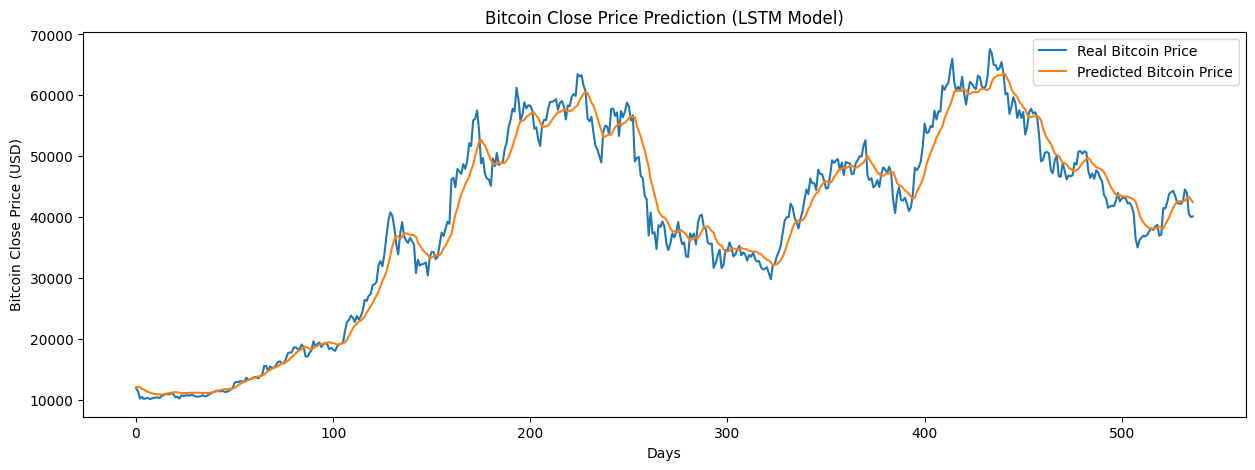

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(real, label="Real Bitcoin Price")
plt.plot(pred, label="Predicted Bitcoin Price")

plt.title("Bitcoin Close Price Prediction (LSTM Model)")
plt.xlabel("Days")
plt.ylabel("Bitcoin Close Price (USD)")
plt.legend()

plt.show()

# Metrics

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(real, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(real, pred)
r2 = r2_score(real, pred)
mape = np.mean(np.abs((real - pred) / real)) * 100

print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("MAPE :", mape, "%")

MSE  : 7684587.784863401
RMSE : 2772.108905664314
MAE  : 2054.9837894391294
R2   : 0.9689139185058768
MAPE : 5.158591688313924 %


# GRU 

In [25]:
#  GRU MODEL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model_gru = Sequential()

model_gru.add(GRU(units=125, activation="tanh", input_shape=(X_train.shape[1], 1)))
model_gru.add(Dense(units=1))

# compile model
model_gru.compile(optimizer="RMSprop", loss="mse")

model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 125)            │        48,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,126 (187.99 KB)

 Trainable params: 48,126 (187.99 KB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [26]:
model_gru.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0018
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8884e-04
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6807e-04
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6022e-04
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3567e-04
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7060e-04
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3349e-04
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3931e-04
Epoch 9/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1975e-04
Epoch 10/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2974e-04


# Predictions

In [27]:
pred = model_gru.predict(X_test)

# inverse scaling
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


# Plot

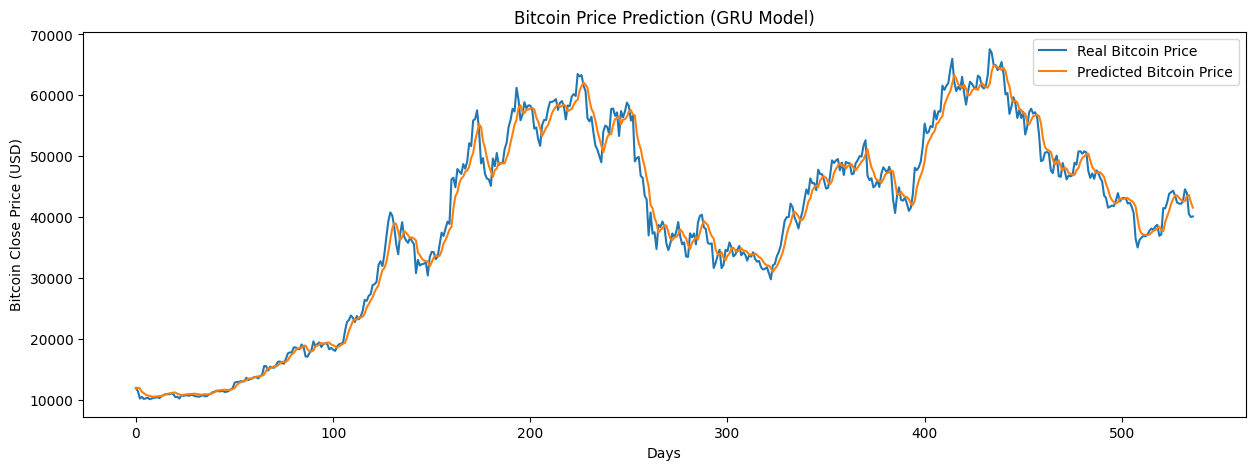

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(real, label="Real Bitcoin Price")
plt.plot(pred, label="Predicted Bitcoin Price")

plt.title("Bitcoin Price Prediction (GRU Model)")
plt.xlabel("Days")
plt.ylabel("Bitcoin Close Price (USD)")
plt.legend()

plt.show()

# RMSE

In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)

RMSE: 2040.7965073049668
